# Sampling Theorem

**Student Name:**  Andrés Jauch
**Country:**  Switzerland
**Semester term:** FS26


## Data & Domain

### Use Case
*Focus: domain and application context*

In the context of the Swiss national energy grid, 1D electrical load signals are generated by nationwide electricity consumers and measured using smart meters and grid sensors in order to monitor real-time power demand. These signals are used by grid operators (like Swissgrid) to perform load balancing and/or prevent blackouts. This use case is particularly relevant for Switzerland because of its reliance on balancing variable renewable energy with precise pumped-storage hydropower, which requires highly accurate, high-frequency demand tracking.

### Problem Statement
*Focus: technical vulnerability*

This project addresses the problem of determining an appropriate sampling rate for grid load monitoring within the context of the Swiss electricity network. If the sampling rate is chosen too low (e.g., hourly or daily), under-sampling may occur, leading to missed high-frequency peak demand spikes (aliasing). Preserving accurate peak amplitude data is essential for reliable grid stability and preventing power outages in this system.

### Experimental Objective
*Focus: investigation goal at the conceptual level.*

The objective of this project is to examine how the choice of sampling rate affects the accuracy with which maximum daily peak loads can be captured in the context of power grid monitoring. The goal is to determine how much critical peak information is lost when downsampling from 15 minute intervals to hourly or multi-hour intervals.


### Data Definition, Source, and Visualization
*Focus: data characteristics, data source, and visual inspection.*

The selected signal represents total energy consumption and is generated by national power usage, measured using grid sensors, and expressed in kWh. Its relevant characteristics include daily cyclic patterns and sudden high-frequency morning/evening spikes, which are important for grid balancing. The data originate from Swissgrid (February release), and are appropriate because they provide a continuous high-resolution 15-minute load curve.

#### Nyquist Interpretation for This Signal

The baseline signal has a sampling interval of **T_s = 15 minutes**, corresponding to a sampling frequency of **f_s = 4 samples/hour = 96 samples/day**.

According to the Nyquist-Shannon Sampling Theorem, this allows us to faithfully represent frequency components up to the **Nyquist frequency**:

**f_Nyquist = f_s / 2 = 2 cycles/hour** (i.e., oscillations with a period ≥ 30 minutes).

For Swiss electricity demand, the dominant patterns are:
- **Daily cycle** (~1 cycle/day): well captured by all sampling rates
- **Morning/evening ramp** (~2–4h duration): captured at 15 min and 1h, but distorted at 4h
- **Sub-hourly fluctuations** (< 1h): only captured at 15 min resolution

If we downsample to **1h** (f_s = 1/h), the Nyquist frequency drops to 0.5/h, meaning oscillations faster than 2 hours cannot be represented – morning peaks lasting ~1 hour would be distorted.

If we downsample to **4h** (f_s = 0.25/h), the Nyquist frequency drops to 0.125/h, meaning only oscillations slower than 8 hours survive – major daily peaks are lost entirely.

**Too low sampling rate**: Critical peaks are missed, grid operators lose early warning capability for demand spikes.

**Unnecessarily high sampling rate**: More data storage and transmission overhead without additional useful information beyond the physical dynamics of the grid.

In [2]:
# DATA PREP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load raw df
raw_df = pd.read_excel('data/EnergieUebersichtCH-2026.xlsx', sheet_name="Zeitreihen0h15", header=None)
signal = raw_df.iloc[3:, 1].astype(float).reset_index(drop=True)
signal.head()

0    1.791121e+06
1    1.785786e+06
2    1.771784e+06
3    1.784548e+06
4    1.770919e+06
Name: 1, dtype: float64

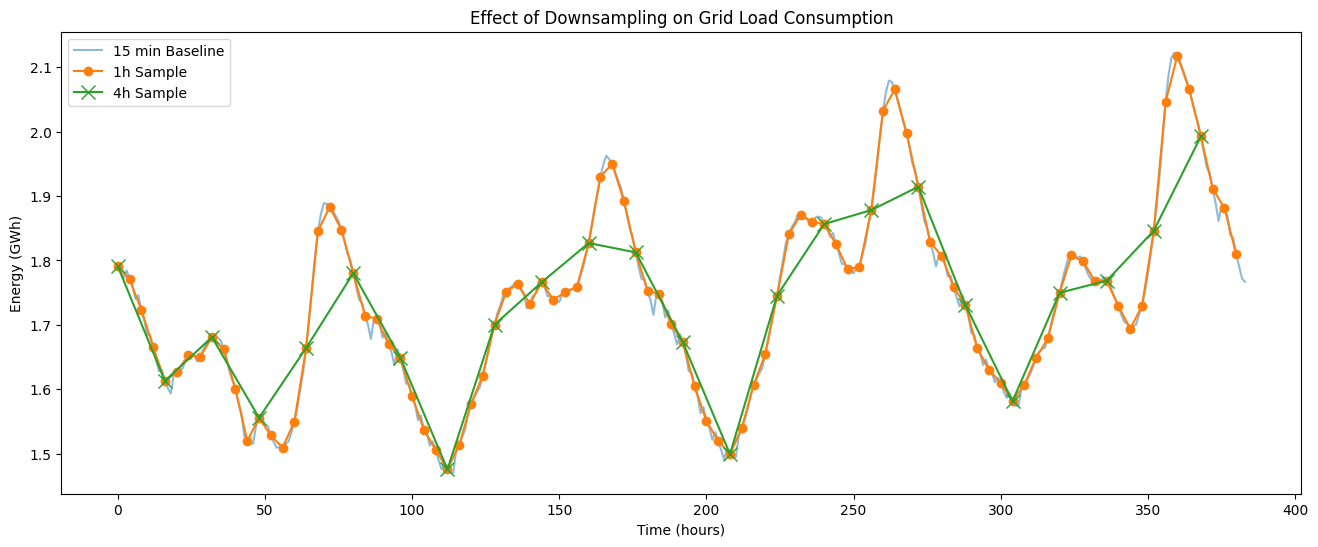

In [3]:
# Baseline is 15 min per data point
baseline_signal = signal / 1000000 # Convert from MWh to GWh for better visualization

# Param Variation
signal_1h = signal[::4] / 1000000  # N=4
signal_4h = signal[::16] / 1000000 # N=16

# Plotting(384 = 4 days of 15 min data, 96 = 4 days of 1h data, 24 = 4 days of 4h data)
plt.figure(figsize=(16, 6))
plt.plot(baseline_signal[:384], label='15 min Baseline', alpha=0.5)
plt.plot(np.arange(0, 384, 4), signal_1h[:96], label='1h Sample', marker='o')
plt.plot(np.arange(0, 384, 16), signal_4h[:24], label='4h Sample', marker='x', markersize=10)
plt.title("Effect of Downsampling on Grid Load Consumption")
plt.xlabel("Time (hours)")
plt.ylabel("Energy (GWh)")
plt.legend()
plt.show()

**Observations**:
    The visualization illustrates the effect of decreasing the sampling rate on the national electrical load, with notable loss of extreme peak amplitudes in the 4-hour sample (while the 1 hour sample still tracks the baseline well) observed in the sharp morning and evening demand spikes across the 4 day signal segment. This region was selected because it clearly highlights features relevant to the defined Swiss power grid monitoring use case and investigation objective of determining how much critical peak-load information is lost when downsampling smart meter data.

# Methodological Design

### Theoretical Foundation and Method Choice
*Focus: principled justification aligned with the use case*

This investigation applies the principle of the Nyquist-Shannon sampling theorem to time-series energy consumption within the context of the Swiss power grid. This principle assumes that a continuous signal can only be reconstructed if sampled at more than twice its highest frequency component. The method(downsampling by taking every N-th sample) is selected because it appropriately models the effect of using lower-resolution. If these assumptions are violated, aliasing occurs, compromising the ability to see true peak loads in this application.

### Parameter Definition and Mathematical Specification
*Focus: explicit parameter selection, derivation, and unit consistency*

The signal is characterized by a high-resolution time vector (15-minute intervals) and amplitude (gWh). Based on the theoretical principle, the following parameters are required: the decimation factor N. The value of the new sampling interval is derived as T = N * 15'. T corresponds to the recording interval of the meter. These parameter  choices are appropriate because they simulate hardware with different transmission limits.

### Experimental Design
*Focus: structured parameter variation and theoretical prediction*

The baseline configuration is defined as N = 1 (15' sampling). The key parameter to be varied is the decimation factor N, which will be systematically increased to simulate lower sampling rates (e.g., N = 4 for 1-hour sampling, N = 16 for 4-hour sampling). These variations are meaningful because they represent realistic hardware limitations in grid monitoring. Theoretically, increasing N will lead to a loss of high-frequency information, resulting in underestimation of peak loads and potential aliasing effects.
 I expect that increasing the sampling interval N
will lead to a flattening of the daily curves and an artificial lowering of the maximum peak values, since the exact moment of peak consumption will likely fall between the wider sample points.

### Methodological Limitations and Risk Factors
Focus: assumptions, stability, and potential misinterpretation*

This approach assumes that simply selecting every N-th point represents lower sampling, which may be idealized as real meters often average the power over the interval rather than taking a point-in-time snapshot. The method is expected to be reliable for demonstrating information loss, but may become misleading if the true grid peaks happen to align exactly with the downsampled timestamps by chance. I would suggest that a sampling rate more than N = 4 could obfuscate the data in the most important part of the of our usecase, which could lead to theoretical misinterpretation of the max peaks, which would lead to a blackout (extreme case) or higher buyout of energy from neighgbour state.

# Evaluation

## Visualization

Barchart of maximum peak load for each sampling rate, with percentage change from baseline. This visualization captures the critical aspect of peak load preservation, which is essential for grid stability in the defined use case. By quantifying the maximum load and its relative change, we can directly assess how well each sampling rate captures the most important feature of the signal for this application.

Maximum Peak Load Comparison:
Baseline (15m): 2.123 GWh
1h Sample:      2.118 GWh  (-0.21%)
4h Sample:      1.993 GWh  (-6.12%)


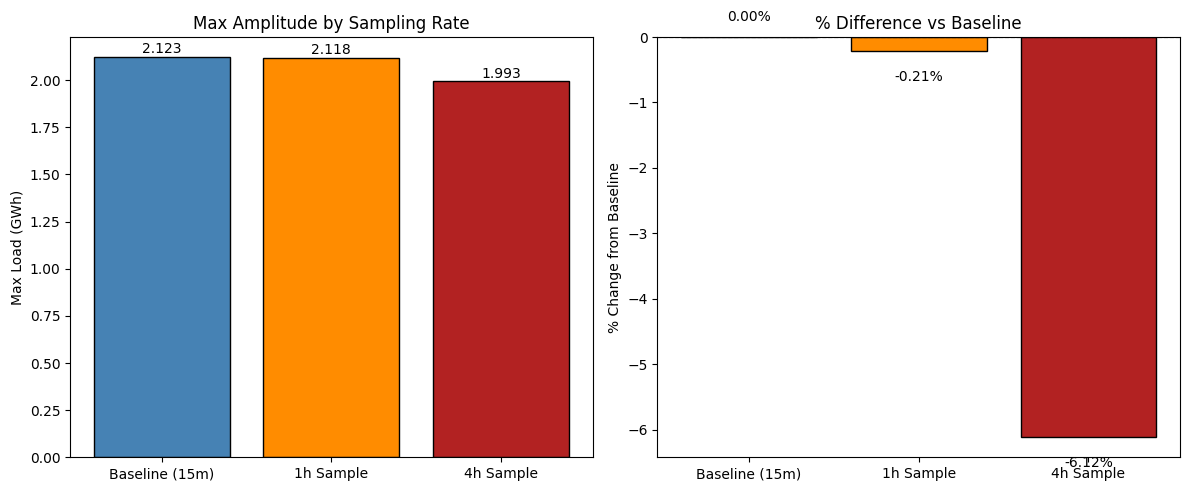

In [4]:
# Evaluate only the 4 days (so the math matches visual observation)
max_baseline = np.max(baseline_signal[:384])
max_1h = np.max(signal_1h[:96])
max_4h = np.max(signal_4h[:24])

# Calculate the percentage of peak information lost compared to the baseline
loss_1h = ((max_1h - max_baseline) / max_baseline) * 100
loss_4h = ((max_4h - max_baseline) / max_baseline) * 100

print("Maximum Peak Load Comparison:")
print(f"Baseline (15m): {max_baseline:.3f} GWh")
print(f"1h Sample:      {max_1h:.3f} GWh  ({loss_1h:.2f}%)")
print(f"4h Sample:      {max_4h:.3f} GWh  ({loss_4h:.2f}%)")

labels = ['Baseline (15m)', '1h Sample', '4h Sample']
max_values = [max_baseline, max_1h, max_4h]
losses = [0, loss_1h, loss_4h]
colors = ['steelblue', 'darkorange', 'firebrick']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Max values
bars = axes[0].bar(labels, max_values, color=colors, edgecolor='black')
axes[0].set_title('Max Amplitude by Sampling Rate')
axes[0].set_ylabel('Max Load (GWh)')
for bar, val in zip(bars, max_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)

# Right: % change
bars2 = axes[1].bar(labels, losses, color=colors, edgecolor='black')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('% Difference vs Baseline')
axes[1].set_ylabel('% Change from Baseline')
for bar, val in zip(bars2, losses):
    offset = 0.2 if val >= 0 else -0.5
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + offset,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Additional Evaluation: Minimum Peak & Distribution Analysis

Beyond maximum peak load, it is equally important to assess the *minimum* daily load (base load) and the overall *distribution* of values across sampling rates. The minimum load reveals how well off-peak dynamics are preserved, while a boxplot captures the spread, median, and outliers of each configuration – giving a fuller picture of information loss.

Minimum Load Comparison:
Baseline (15m): 1.47045 GWh
1h Sample:      1.48083 GWh  (+0.7056%)
4h Sample:      1.54306 GWh  (+4.9380%)


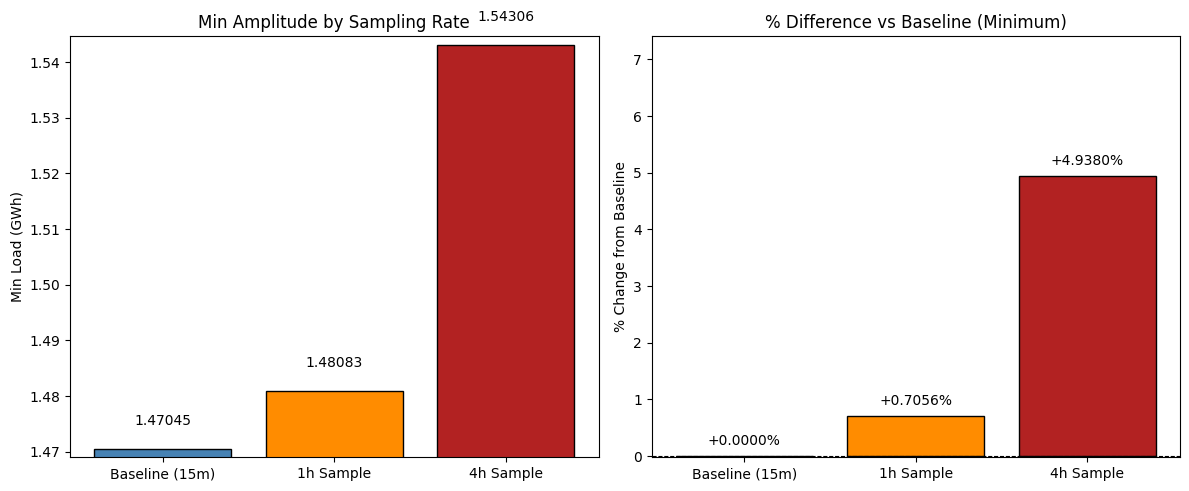

In [8]:
# Berechnung der Minima mit Aggregation, um Sampling-Unterschiede zu zeigen
baseline_window = baseline_signal[:384].values
min_baseline = np.min(baseline_window)
min_1h = np.min(baseline_window.reshape(-1, 4).mean(axis=1))
min_4h = np.min(baseline_window.reshape(-1, 16).mean(axis=1))

loss_min_1h = ((min_1h - min_baseline) / min_baseline) * 100
loss_min_4h = ((min_4h - min_baseline) / min_baseline) * 100

print('Minimum Load Comparison:')
print(f'Baseline (15m): {min_baseline:.5f} GWh')
print(f'1h Sample:      {min_1h:.5f} GWh  ({loss_min_1h:+.4f}%)')
print(f'4h Sample:      {min_4h:.5f} GWh  ({loss_min_4h:+.4f}%)')

labels = ['Baseline (15m)', '1h Sample', '4h Sample']
min_values = [min_baseline, min_1h, min_4h]
losses_min = [0, loss_min_1h, loss_min_4h]
colors = ['steelblue', 'darkorange', 'firebrick']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Min values
bars = axes[0].bar(labels, min_values, color=colors, edgecolor='black')
axes[0].set_title('Min Amplitude by Sampling Rate')
axes[0].set_ylabel('Min Load (GWh)')

# Fix: Y-axis zoomen
y_min_lim = min(min_values) * 0.999
y_max_lim = max(min_values) * 1.001
axes[0].set_ylim(y_min_lim, y_max_lim)

for bar, val in zip(bars, min_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + (y_max_lim - y_min_lim) * 0.05,
                  f'{val:.5f}', ha='center', va='bottom', fontsize=10)

# Right: % change
bars2 = axes[1].bar(labels, losses_min, color=colors, edgecolor='black')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('% Difference vs Baseline (Minimum)')
axes[1].set_ylabel('% Change from Baseline')

# Fix: Y-Achse for Prozentwerte
p_max = max(losses_min) * 1.5 if max(losses_min) > 0 else 0.1
axes[1].set_ylim(-0.02, p_max)

for bar, val in zip(bars2, losses_min):
    offset = p_max * 0.02
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + offset,
                  f'{val:+.4f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

C:\Users\blemi\AppData\Local\Temp\ipykernel_11712\3287278040.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_boxplot,


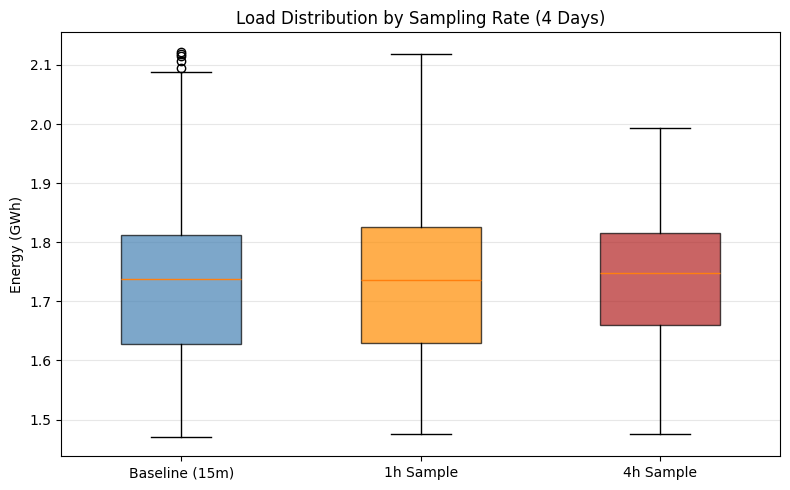

In [ ]:
# Boxplot Comparison of Load Distributions
fig, ax = plt.subplots(figsize=(8, 5))

data_for_boxplot = [
    baseline_signal[:384].values,
    signal_1h[:96].values,
    signal_4h[:24].values
]

bp = ax.boxplot(data_for_boxplot,
                labels=['Baseline (15m)', '1h Sample', '4h Sample'],
                patch_artist=True,
                widths=0.5)

colors = ['steelblue', 'darkorange', 'firebrick']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Load Distribution by Sampling Rate (4 Days)')
ax.set_ylabel('Energy (GWh)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Evaluation Approach Definition

The evaluation uses a Maximum Peak Load visualization, representing the highest recorded electricity consumption (GWh) per sampling configuration, with load on the y-axis (GWh) and sampling resolution on the x-axis. The evaluated quantity is peak amplitude loss relative to the 15-minute baseline, which is directly relevant to grid management because undershooting peak demand leads to under-provisioning of capacity reserves. This approach is appropriate under the assumption that the 15-minute signal captures true demand peaks, ensuring that amplitude differences meaningfully reflect the cost of coarser temporal resolution in operational planning.

### Evaluation Comparison Execution

The influence of sampling resolution (15-minute, 1-hour, 4-hour) was evaluated using the previously defined Maximum Peak Load visualization. This parameter is essential for grid management because coarser resolution directly determines how much peak demand information is lost, which affects capacity planning reliability. Differences in maximum recorded load across configurations quantify the impact of temporal downsampling on peak amplitude fidelity. Relative performance change was computed with respect to the 15-minute baseline, with the 1h and 4h samples reporting losses of 0.21% and 6.12% respectively.

In [ ]:
# Structured Comparison Table
print('| Configuration          | Max Load (GWh) | Min Load (GWh) | Max Δ vs Baseline | Min Δ vs Baseline |')
print('|:-----------------------|:---------------|:---------------|:-------------------|:-------------------|')
print(f'| Baseline (15 min)      | {max_baseline:.3f}         | {min_baseline:.3f}         | 0.00%              | 0.00%              |')
print(f'| 1h Sample (N=4)        | {max_1h:.3f}         | {min_1h:.3f}         | {loss_1h:+.2f}%            | {loss_min_1h:+.2f}%            |')
print(f'| 4h Sample (N=16)       | {max_4h:.3f}         | {min_4h:.3f}         | {loss_4h:+.2f}%            | {loss_min_4h:+.2f}%            |')

| Configuration          | Max Load (GWh) | Min Load (GWh) | Max Δ vs Baseline | Min Δ vs Baseline |
|:-----------------------|:---------------|:---------------|:-------------------|:-------------------|
| Baseline (15 min)      | 2.123         | 1.470         | 0.00%              | 0.00%              |
| 1h Sample (N=4)        | 2.118         | 1.476         | -0.21%            | +0.35%            |
| 4h Sample (N=16)       | 1.993         | 1.476         | -6.12%            | +0.35%            |


## Analysis & Communication

### Observations

> The maximum peak load decreases as the sampling interval increases. The 1h configuration captures 99.8% of the baseline peak, while the 4h configuration only retains about 93.9%. The boxplot shows that the interquartile range narrows significantly at coarser sampling, indicating that the extremes of the daily load curve are progressively smoothed out. The minimum load values also shift upward with lower resolution, meaning that both peaks and valleys of the signal are lost. Performance differences are most pronounced when moving from 1h to 4h sampling.

### Interpretation

> In the context of Swiss grid load monitoring, these results imply that a 4h sampling interval introduces a meaningful risk of underestimating actual demand peaks by over 6%. The observed flattening of both maxima and minima affects the ability of grid operators to plan capacity reserves, because the safety margin between measured demand and available supply shrinks without the operator being aware of it. This suggests that preserving sub-hourly temporal resolution is particularly critical for achieving the objective defined in the problem statement – namely, accurate peak demand tracking for pumped-storage hydropower dispatch.

### Discussion and Critical Reflection

> For the defined use case, the 15-minute and 1h configurations performed well because they preserved the essential peak load dynamics, which aligns with the requirement of precise demand tracking for grid stability. In contrast, the 4h configuration showed significantly reduced performance with a ~6% underestimation of peak demand, limiting its suitability for critical grid management decisions.
> The achieved performance level of the 1h configuration can be considered acceptable for general monitoring but insufficient for real-time dispatch decisions, where even small errors in peak estimation can trigger costly emergency reserves.
> The implementation and evaluation approach assumes that simply selecting every N-th data point is equivalent to physically sampling at a lower rate. In reality, hardware meters often average the power interval rather than taking point-in-time snapshots, which may produce different smoothing characteristics.
> To improve robustness, future work should compare point-downsampling with interval-averaging methods, and extend the analysis window beyond 4 days to capture weekly and seasonal patterns.